# run_poc_simulation.py

## Imports

### Libraries

In [1]:
import numpy as np
import os
import sys

#### Ensure /src is importable

In [2]:
sys.path.append(os.path.abspath(".."))

#### Set the true top-level /outputs path

In [3]:
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
output_dir = os.path.join(project_root, "outputs")
os.makedirs(output_dir, exist_ok=True)

In [4]:
print("✅ Output path set to:", output_dir)

✅ Output path set to: c:\Users\MissV\OneDrive\Documents\Education\CityU\2025SpringQ6\DS623\TP\DS623-Optimotion\outputs


### Core computation imports

In [5]:
from src.robotic_arm import forward_kinematics
from src.optimizer import compute_cost, compute_gradients, optimize_arm

### Plot utilities (import as functions or call via CLI as needed)

In [6]:
from src.visualizations.cost_convergence_plot import plot_cost_convergence
from src.visualizations.pose_comparison_plot import plot_pose_comparison

## Define Run Simulation

In [ ]:
def run_simulation():
    # Initial angles
    theta1_init = np.radians(20)
    theta2_init = np.radians(10)
    # Target position
    target_x, target_y = 1.2, 1.3

    # Run optimization
    theta1_final, theta2_final, history = optimize_arm(
        theta1_init,
        theta2_init,
        target_x,
        target_y,
        learning_rate=0.1,
        iterations=50
    )
    
    # Extract costs for plotting
    costs = [entry[2] for entry in history]

    plot_cost_convergence(
        costs, 
        title="Cost Convergence (PoC Run)",
        output_dir=output_dir, 
        filename="poc_cost_convergence.png"
    )

    # Plot arm pose comparison (initial vs. optimized)
    plot_pose_comparison(
        theta1_init, theta2_init,
        theta1_final, theta2_final,
        title="Pose Comparison: Initial vs. Optimized (PoC Run)",
        output_dir=output_dir,
        filename="poc_pose_comparison.png"
    )

    # Output summary
    print(f"✅ Final Angles: θ1 = {np.degrees(theta1_final):.2f}°, θ2 = {np.degrees(theta2_final):.2f}°")
    print(f"✅ Final Cost: {costs[-1]:.4f}")

## Main Run

Iteration 1: Cost = 0.7594
Iteration 11: Cost = 0.2074
Iteration 21: Cost = 0.2090
Iteration 31: Cost = 0.2100
Iteration 41: Cost = 0.2221
Iteration 50: Cost = 0.1451
✅ Cost convergence plot saved to: outputs\poc_cost_convergence.png


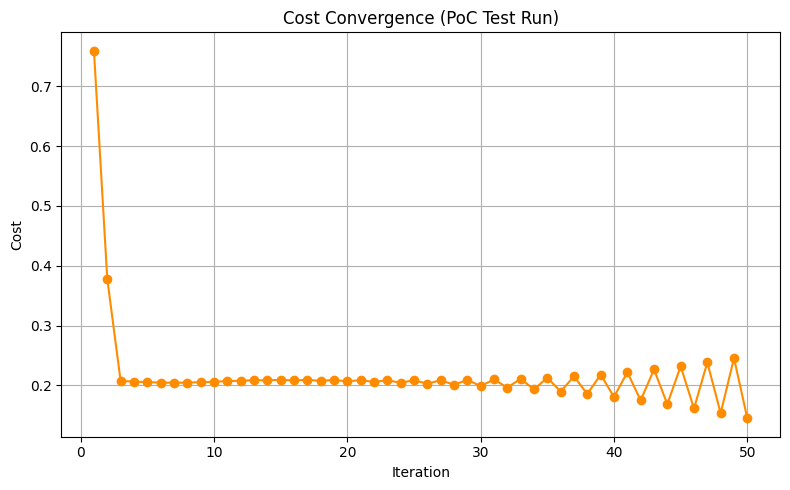

✅ Pose comparison plot saved to: outputs\pose_comparison_initial_vs_optimized.png


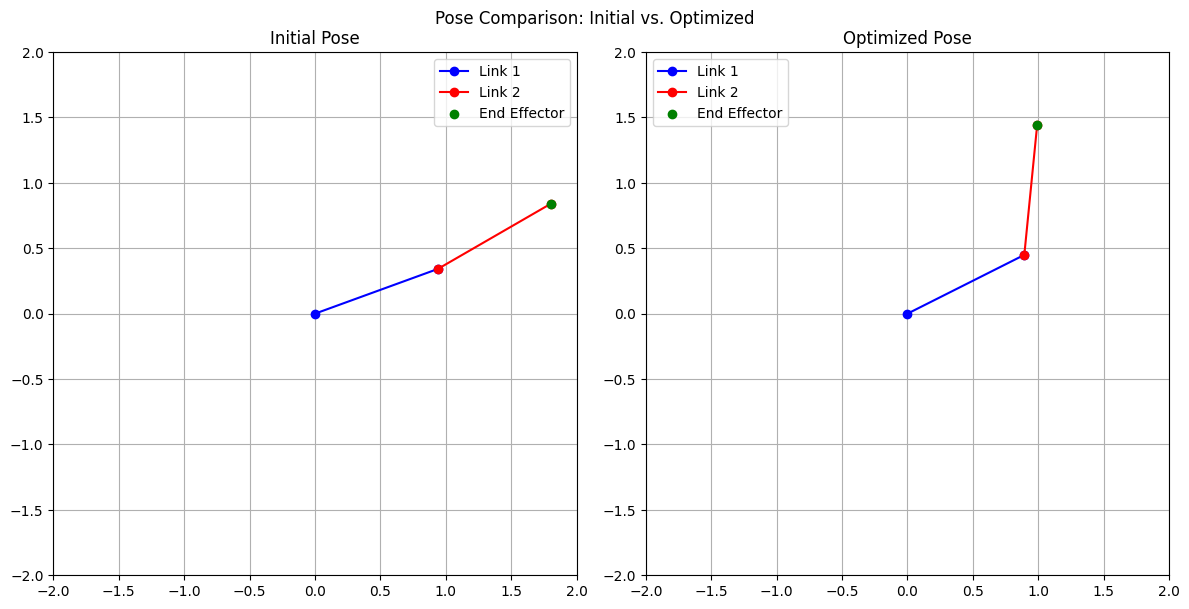

✅ Final Angles: θ1 = 26.70°, θ2 = 57.65°
✅ Final Cost: 0.1451


In [8]:
if __name__ == "__main__":
    run_simulation()